In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os

In [ ]:
# =============================================================================
# SECTION 1 — EPIDEMIC SIMULATOR
# =============================================================================

def generate_fixed_epidemic_dataset(
        p1_val, p2_val, population_size=2000, days=100,
        inc_days=7, dur_days=7, seed=42):
    """
    SEAIR stochastic agent-based epidemic simulation.
    States: S=0 E=1 A=2 I=3 R=4
    Writes timed_edges.csv and individual_day_state.csv into
    a sub-folder named  p1_{p1_val}_p2_{p2_val}/
    """
    if seed is not None:
        np.random.seed(seed)
        import random as _rnd
        _rnd.seed(seed)

    import random

    folder_name = f"p1_{p1_val}_p2_{p2_val}"
    os.makedirs(folder_name, exist_ok=True)
    print(f"Simulating: {folder_name}...")

    state_map   = {0: 'S', 1: 'E', 2: 'A', 3: 'I', 4: 'R'}
    states      = np.zeros(population_size, dtype=int)
    state_timers = np.zeros(population_size, dtype=int)

    # Seed 15 initial infected individuals
    initial_infected = np.random.choice(population_size, size=15, replace=False)
    states[initial_infected] = 3

    all_edges     = []
    state_history = np.zeros((days, population_size), dtype=int)
    history_counts = {'S': [], 'E': [], 'A': [], 'I': [], 'R': []}

    for d in range(days):
        # Daily random contacts (average degree = 4)
        num_edges = population_size * 4 // 2
        u = np.random.randint(0, population_size, num_edges)
        v = np.random.randint(0, population_size, num_edges)
        valid = u != v
        u, v = u[valid], v[valid]

        all_edges.append(np.column_stack((np.full(len(u), d), u, v)))

        # Transmission: S + (A|I) → E
        infectious_nodes = set(np.where((states == 2) | (states == 3))[0])
        new_exposures = set()
        for i in range(len(u)):
            n1, n2 = u[i], v[i]
            if states[n1] == 0 and n2 in infectious_nodes:
                if random.random() < p1_val:
                    new_exposures.add(n1)
            elif states[n2] == 0 and n1 in infectious_nodes:
                if random.random() < p1_val:
                    new_exposures.add(n2)

        # E → A or I after incubation
        ready_to_infect = (states == 1) & (state_timers >= inc_days)
        num_ready = np.sum(ready_to_infect)
        if num_ready > 0:
            is_symptomatic = np.random.rand(num_ready) < p2_val
            states[ready_to_infect] = np.where(is_symptomatic, 3, 2)
            state_timers[ready_to_infect] = 0

        # A|I → R after duration
        ready_to_recover = ((states == 2) | (states == 3)) & (state_timers >= dur_days)
        states[ready_to_recover] = 4
        state_timers[ready_to_recover] = 0

        for node in new_exposures:
            states[node] = 1
            state_timers[node] = 0

        active = (states == 1) | (states == 2) | (states == 3)
        state_timers[active] += 1

        state_history[d] = states
        for k, v_state in state_map.items():
            history_counts[v_state].append(np.sum(states == k))

    # --- Export ---
    final_edges = np.vstack(all_edges)
    pd.DataFrame(final_edges, columns=['day', 'u', 'v']).to_csv(
        os.path.join(folder_name, "timed_edges.csv"), index=False)

    days_g, nodes_g = np.mgrid[0:days, 0:population_size]
    df_states = pd.DataFrame({
        'day':      days_g.flatten(),
        'node':     nodes_g.flatten(),
        'state_int': state_history.flatten()
    })
    df_states['state'] = df_states['state_int'].map(state_map)
    df_states.drop(columns=['state_int'], inplace=True)
    df_states.to_csv(os.path.join(folder_name, "individual_day_state.csv"), index=False)

    # --- Plot ---
    t = np.arange(days)
    plt.figure(figsize=(10, 6))
    plt.plot(t, history_counts['S'], label='Susceptible (S)', color='brown',  linestyle='--')
    plt.plot(t, history_counts['E'], label='Exposed (E)',     color='purple')
    plt.plot(t, history_counts['I'], label='Infected (I)',    color='red',    linewidth=2)
    plt.plot(t, history_counts['R'], label='Recovered (R)',   color='green',  linestyle='--')
    plt.title(f"Epidemic Curve: p1={p1_val}, p2={p2_val}")
    plt.xlabel("Day"); plt.ylabel("Population Count")
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(folder_name, "epidemic_curve.png"))
    plt.show(); plt.close()

Starting batch data generation...
Simulating: p1_0.2_p2_0.2...


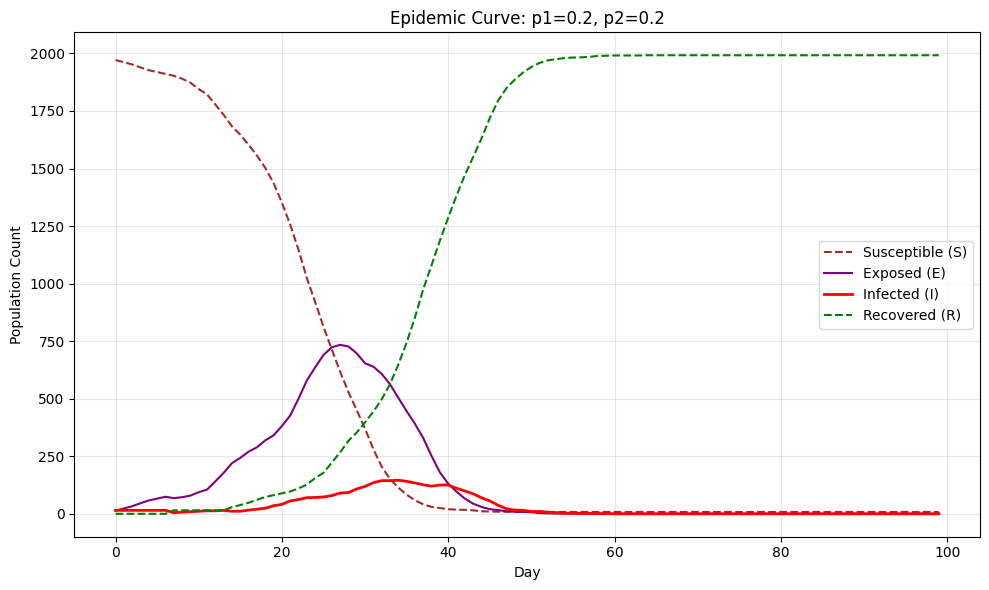

Simulating: p1_0.25_p2_0.1...


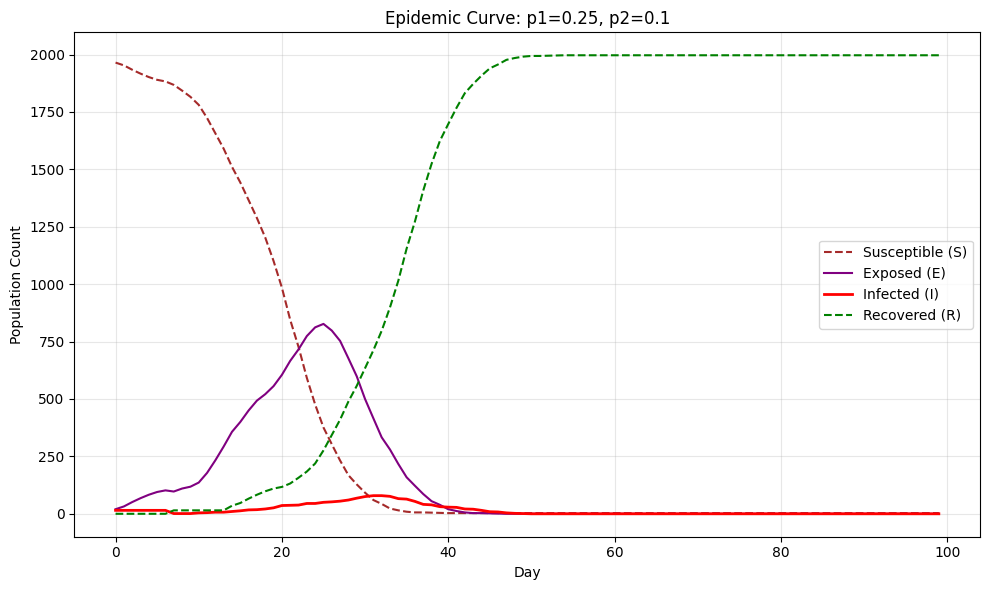

Simulating: p1_0.12_p2_0.1...


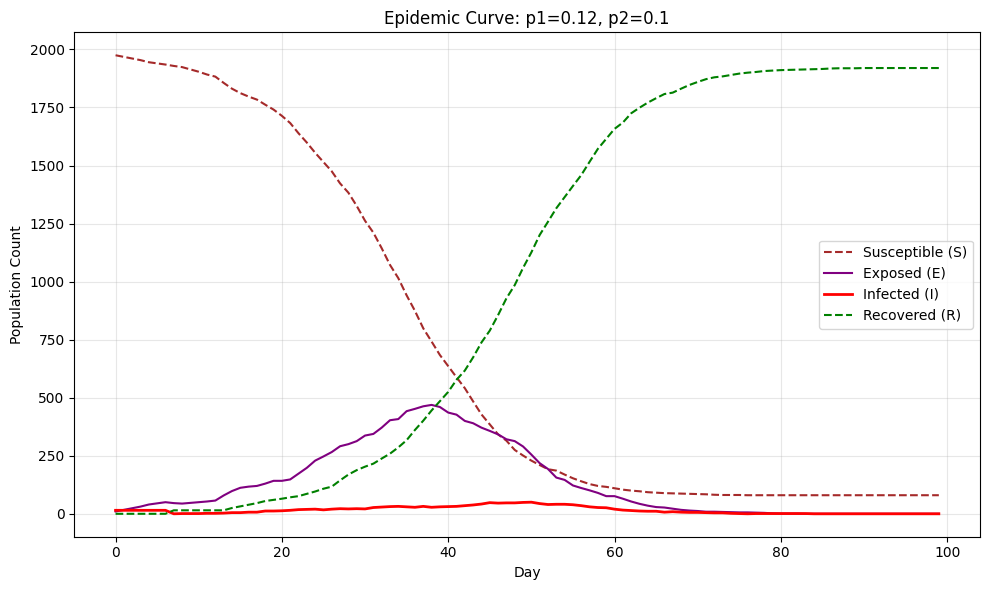

Simulating: p1_0.15_p2_0.05...


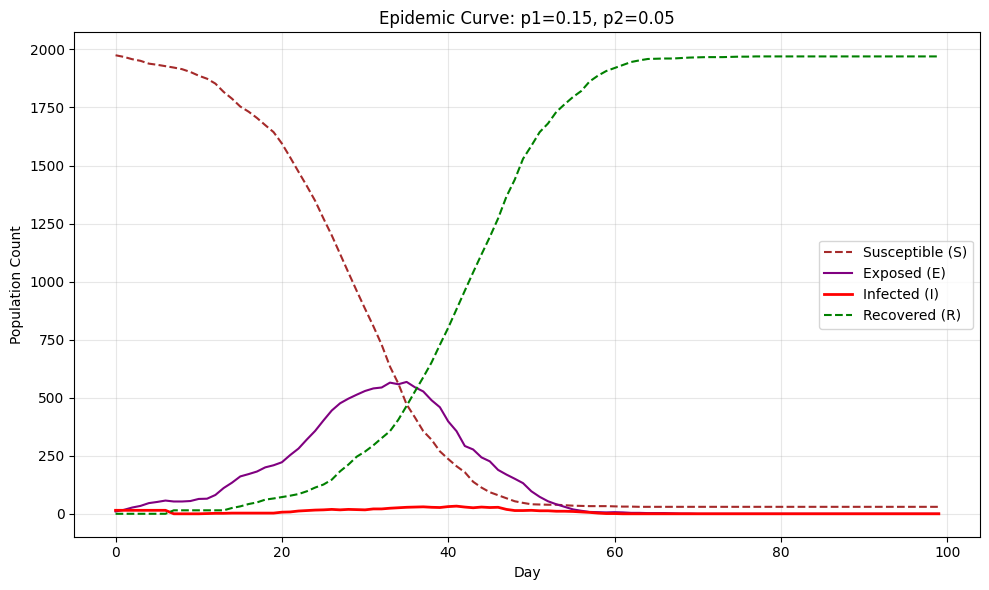

Simulating: p1_0.2_p2_0.1...


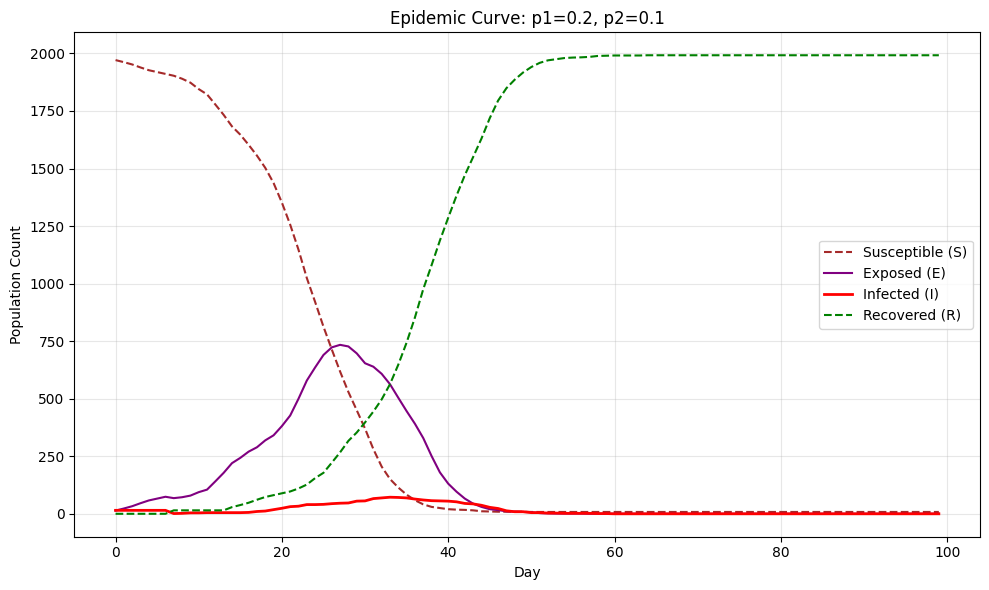

Simulating: p1_0.15_p2_0.1...


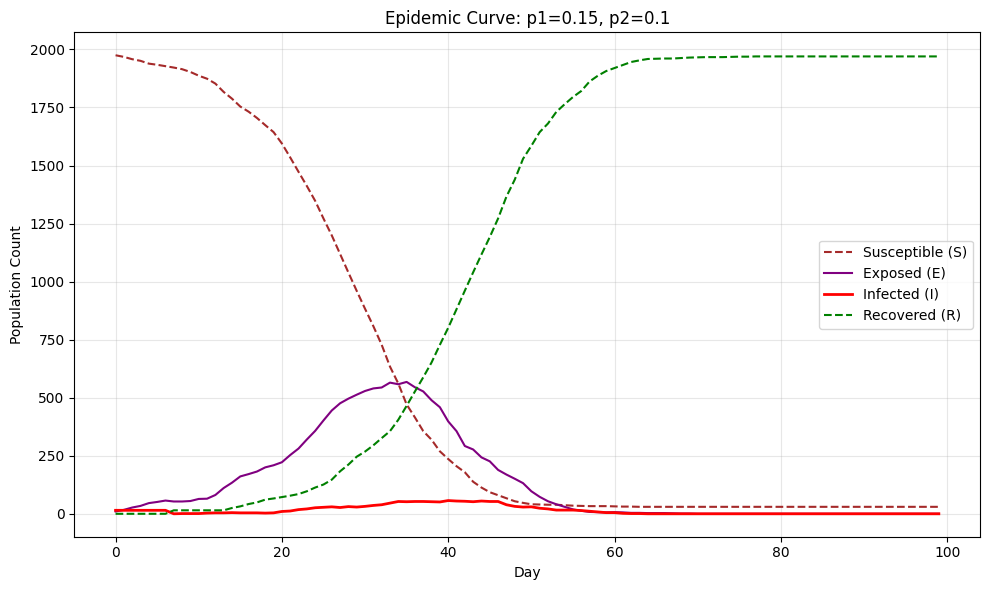

Simulating: p1_0.2_p2_0.05...


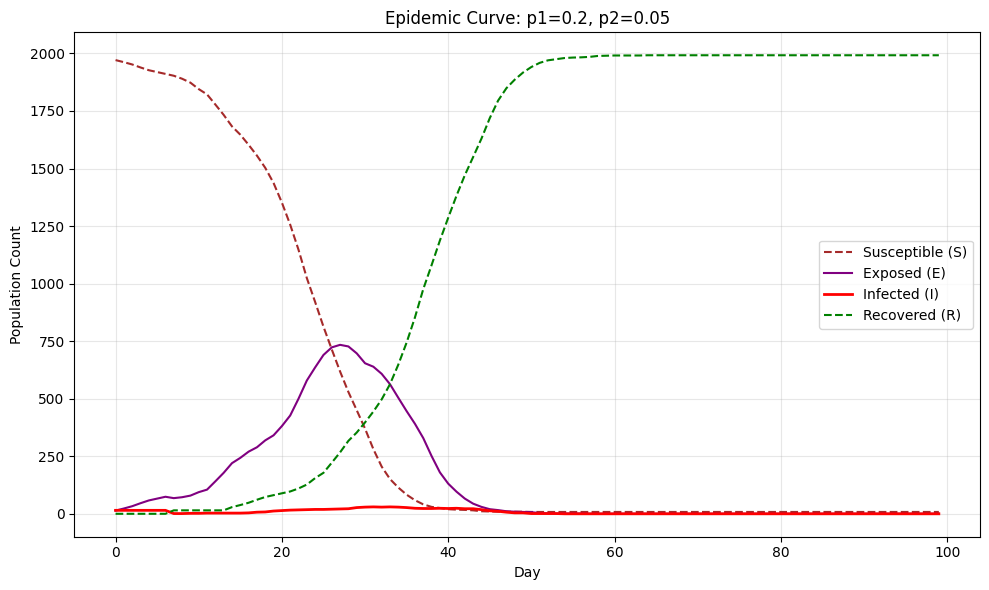

Simulating: p1_0.12_p2_0.05...


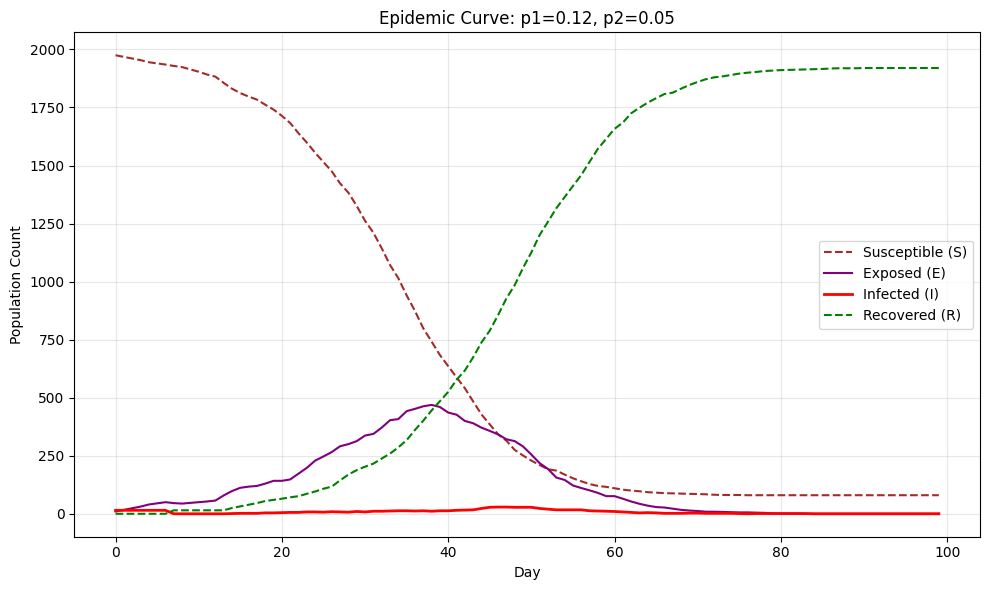

Simulating: p1_0.25_p2_0.05...


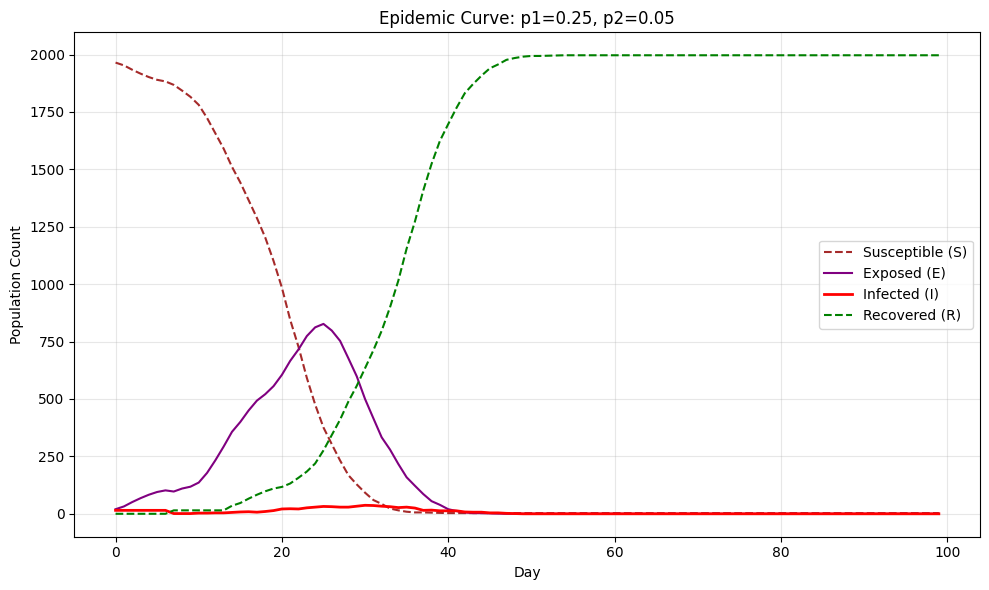

Simulating: p1_0.15_p2_0.2...


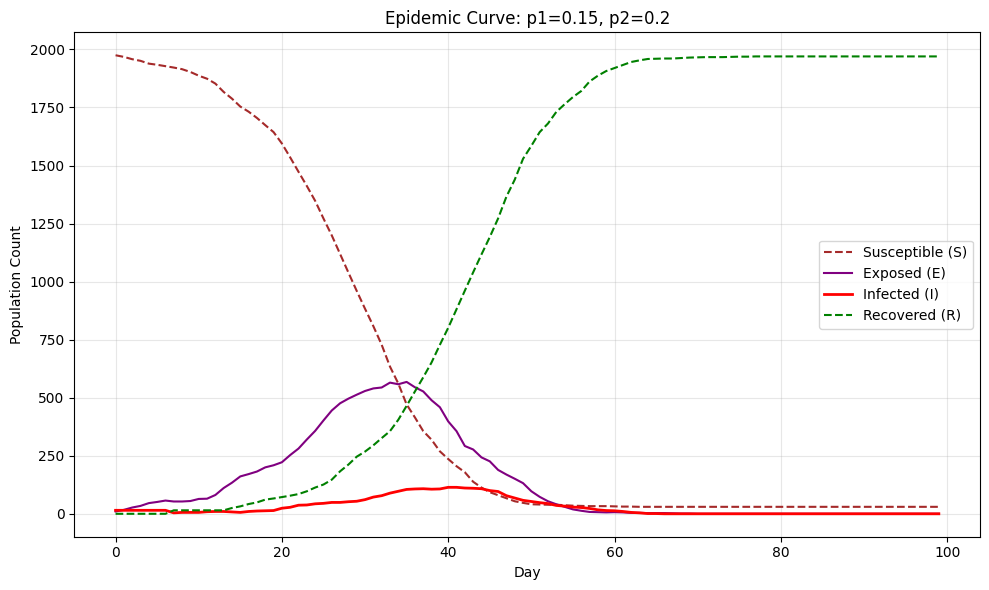

Simulating: p1_0.25_p2_0.2...


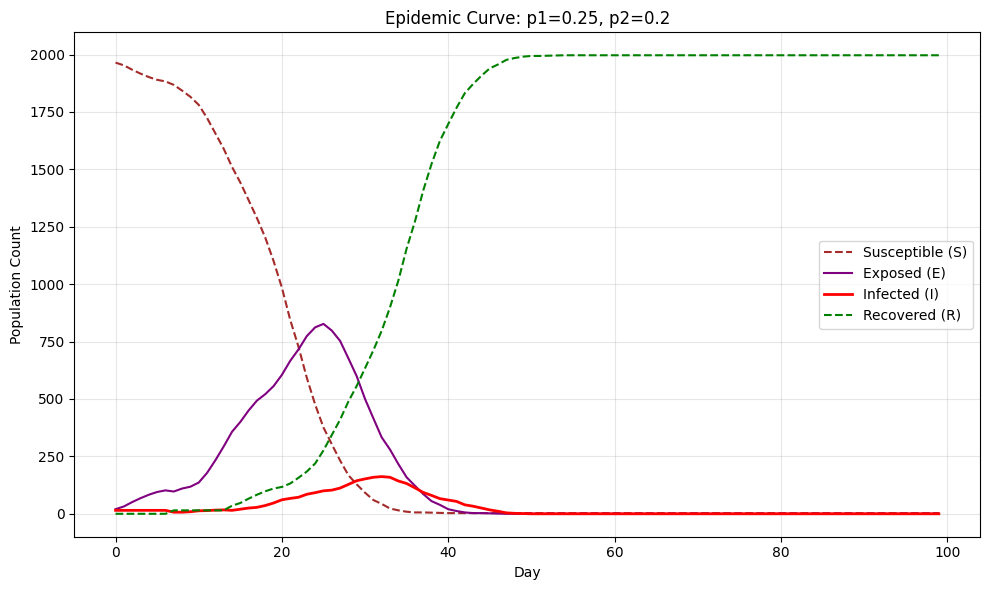

Simulating: p1_0.12_p2_0.2...


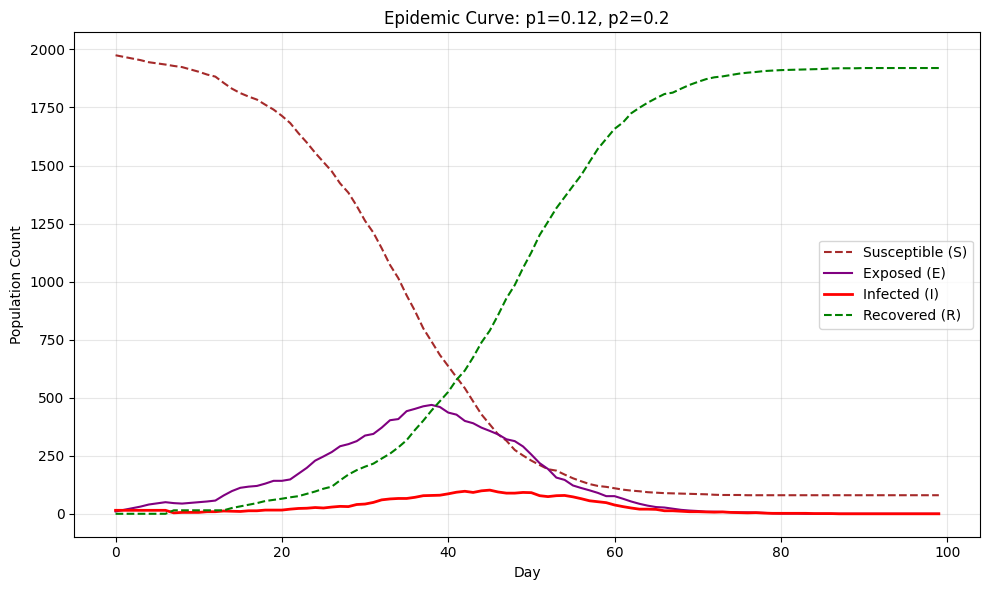

All datasets generated successfully!


In [ ]:
# =============================================================================
# SECTION 2 — BATCH SIMULATION
# =============================================================================

p_array = [
    (0.2, 0.2),  (0.25, 0.1), (0.12, 0.1),
    (0.15, 0.05),(0.2, 0.1),  (0.15, 0.1),
    (0.2, 0.05), (0.12, 0.05),(0.25, 0.05),
    (0.15, 0.2), (0.25, 0.2), (0.12, 0.2)
]

if __name__ == "__main__":
    print("Starting batch data generation...")
    for p1, p2 in p_array:
        generate_fixed_epidemic_dataset(p1_val=p1, p2_val=p2)
    print("All datasets generated successfully!")


In [ ]:
# =============================================================================
# SECTION 3 — BASE CLASS: EpiInferContact
# =============================================================================

class EpiInferContact:
    """
    Infrastructure layer: adjacency dict, contact lookup, single-step
    exposure probability and naive stochastic predict.
    """

    def __init__(self, population_ids, contacts_history,
                 incubation_period=7, infection_duration=7):
        self.population = set(population_ids)
        self.contacts   = contacts_history
        self.inc        = incubation_period
        self.duration   = infection_duration

        self.adj = {}
        for day, meets in self.contacts.items():
            self.adj[day] = {pid: set() for pid in self.population}
            for u, v in meets:
                if u in self.adj[day]: self.adj[day][u].add(v)
                if v in self.adj[day]: self.adj[day][v].add(u)

        self.max_contact_day = max(self.adj.keys()) if self.adj else -1

    def _get_contacts(self, person, day):
        target_day = min(day, self.max_contact_day)
        if target_day in self.adj and person in self.adj[target_day]:
            return self.adj[target_day][person]
        return set()

    def find_prob(self, bel_asymp, s, p1, d):
        contacts_of_s = self._get_contacts(s, d)
        count = sum(1 for x in contacts_of_s if x in bel_asymp)
        return 1.0 - (1.0 - p1) ** count

    def predict(self, bel_asymp, bel_susc, p1, d):
        """Naive (slow) predict — kept for reference; subclass overrides."""
        import random
        believed_new_asymp = set()
        for s in bel_susc:
            p = self.find_prob(bel_asymp, s, p1, d)
            if random.random() < p:
                believed_new_asymp.add(s)
        return believed_new_asymp

In [ ]:
# =============================================================================
# SECTION 4 — EpiInferContactRolling (v3 with all structural fixes)
# =============================================================================

class EpiInferContactRolling(EpiInferContact):
    """
    Optimised + structurally corrected subclass.

    Key corrections vs v2:
      FIX A — bel_inf participates in transmission (_predict_fast now accepts
               both bel_asymp and bel_inf as infectious sources)
      FIX B — No more large_improvement jump; pure dampened EWA update
      FIX C — Phase-aware freeze via _is_declining()
      FIX D — Calibration uses E+I combined target, not I alone
      FIX E — RMSE averaged over num_calib_mc runs per grid point
      FIX F — Grid ceiling raised to 0.55
    """

    # ------------------------------------------------------------------
    # FIX A — Core forward simulation: bel_inf also transmits
    # ------------------------------------------------------------------
    def contact_infer_core_with_history(
            self, p1, p2, history_asymp, history_inf,
            start_day, end_day, known_immune):
        """
        SEAIR belief propagation.

        FIX A: In the simulator, both A (asymptomatic) and I (symptomatic)
        people spread the disease.  The correct mapping is:
          bel_asymp  ≈  E (incubating, not yet spreading in original but
                          conceptually the newly-exposed cohort)
          bel_inf    ≈  A + I (post-incubation infectious people)

        So transmission must come from BOTH bel_asymp and bel_inf.
        _predict_fast now takes the union of these two sets as sources.
        """
        hist_new_asymp = dict(history_asymp)
        hist_new_inf   = dict(history_inf)
        current_immune = set(known_immune) if known_immune else set()

        bel_asymp = set()
        for dk in range(start_day - self.inc + 1, start_day + 1):
            if dk in hist_new_asymp:
                bel_asymp.update(hist_new_asymp[dk])

        bel_inf = set()
        for dk in range(start_day - self.duration + 1, start_day + 1):
            if dk in hist_new_inf:
                bel_inf.update(hist_new_inf[dk])

        recovered = set(current_immune)
        for dk, inf_set in hist_new_inf.items():
            if dk + self.duration <= start_day:
                recovered.update(inf_set)

        results = {}

        for d in range(start_day, end_day):
            non_susc = bel_asymp | bel_inf | recovered
            bel_susc = self.population - non_susc

            # FIX A: pass bel_inf as second infectious source
            new_asymp_next = self._predict_fast(bel_asymp, bel_inf, bel_susc, p1, d)
            hist_new_asymp[d + 1] = new_asymp_next

            source_day = (d + 1) - self.inc
            new_inf_next = set()
            if source_day in hist_new_asymp:
                candidates = list(hist_new_asymp[source_day])
                if candidates:
                    mask = np.random.random(len(candidates)) < p2
                    new_inf_next = {candidates[i] for i in np.where(mask)[0]}
            hist_new_inf[d + 1] = new_inf_next

            bel_asymp.update(new_asymp_next)
            drop_a = d - self.inc + 1
            if drop_a in hist_new_asymp:
                bel_asymp -= hist_new_asymp[drop_a]

            bel_inf.update(new_inf_next)
            drop_i = d - self.duration + 1
            if drop_i in hist_new_inf:
                newly_recovered = hist_new_inf[drop_i]
                bel_inf   -= newly_recovered
                recovered |= newly_recovered

            results[d + 1] = len(bel_inf)

        return results

    # ------------------------------------------------------------------
    # FIX A — Vectorised prediction: union of bel_asymp + bel_inf
    # ------------------------------------------------------------------
    def _predict_fast(self, bel_asymp, bel_inf, bel_susc, p1, d):
        """
        FIX A: infectious = bel_asymp ∪ bel_inf.

        Both E-phase (bel_asymp) and post-incubation (bel_inf ≈ A+I)
        individuals spread the disease, matching the simulator.
        Using the union means the effective R0 now matches the simulator's
        R0 = p1 × mean_degree × (inc + dur), not just p1 × mean_degree × inc.
        """
        infectious = bel_asymp | bel_inf
        if not infectious or not bel_susc:
            return set()

        target_day = min(d, self.max_contact_day)
        adj_d = self.adj.get(target_day, {})

        contact_counts: dict[int, int] = {}
        for a in infectious:
            for nb in adj_d.get(a, set()):
                if nb in bel_susc:
                    contact_counts[nb] = contact_counts.get(nb, 0) + 1

        if not contact_counts:
            return set()

        at_risk = list(contact_counts.keys())
        counts  = np.fromiter(
            (contact_counts[s] for s in at_risk),
            dtype=np.int32, count=len(at_risk))
        probs = 1.0 - (1.0 - p1) ** counts
        rolls = np.random.random(len(at_risk))
        return {at_risk[i] for i in np.where(rolls < probs)[0]}

    # ------------------------------------------------------------------
    # FIX C — Epidemic phase detection helper
    # ------------------------------------------------------------------
    @staticmethod
    def _is_declining(training_data, current_day, peak_fraction=0.10, min_window=5):
        """
        Return True when the epidemic is firmly past its peak and no longer
        carries identifiable signal for p1/p2 calibration.

        Criteria (both must hold):
          1. Current active count < peak_fraction × peak_count
          2. Active count has been non-increasing for at least min_window days

        When True, the caller should freeze parameters rather than recalibrate.
        """
        if not training_data:
            return False

        counts = [training_data.get(d, 0) for d in range(max(training_data.keys()) + 1)]
        if not counts:
            return False

        peak = max(counts)
        if peak < 5:  # epidemic never really started — don't freeze
            return False

        current = training_data.get(current_day, 0)
        if current > peak * peak_fraction:
            return False

        # Check monotone decline for the last min_window days
        recent = [training_data.get(d, 0)
                  for d in range(current_day - min_window + 1, current_day + 1)]
        return all(recent[i] >= recent[i + 1] for i in range(len(recent) - 1))

    # ------------------------------------------------------------------
    # FIX D+E — Multi-run RMSE on E+I combined target
    # ------------------------------------------------------------------
    def _calculate_rmse_for_params(
            self, p1, p2, eval_days,
            h_asymp, h_inf, h_rec, training_data,
            rollout_steps: int = 5,
            num_calib_mc: int = 3):
        """
        FIX D: training_data should be E+I counts (total active disease burden).
               This is set by the caller — see the main loop.

        FIX E: Average RMSE over num_calib_mc stochastic runs so the grid
               search ranking is not dominated by a single noise realization.

        Each run uses a different seed derived from the base seed so draws
        are independent but the same set of seeds is used for every candidate
        (p1, p2), keeping comparisons fair.
        """
        base_seed = int(list(eval_days)[0]) % (2 ** 32)
        lookback  = self.inc + self.duration + 1

        sq_err_sum, count = 0.0, 0

        for mc in range(num_calib_mc):
            rng_state = np.random.get_state()
            np.random.seed((base_seed + mc * 7919) % (2 ** 32))

            for d in eval_days:
                h_asymp_d = {k: h_asymp[k]
                             for k in range(d - lookback, d) if k in h_asymp}
                h_inf_d   = {k: h_inf[k]
                             for k in range(d - lookback, d) if k in h_inf}
                rec_d = h_rec.get(d, set())

                res = self.contact_infer_core_with_history(
                    p1, p2, h_asymp_d, h_inf_d,
                    d - 1, d + rollout_steps, rec_d)

                for step in range(1, rollout_steps + 1):
                    target = d + step
                    if target in res and target in training_data:
                        sq_err_sum += (res[target] - training_data[target]) ** 2
                        count      += 1

            np.random.set_state(rng_state)

        return math.sqrt(sq_err_sum / count) if count > 0 else float('inf')

    # ------------------------------------------------------------------
    # FIX B+F — Pure dampened calibration, wider grid, no collapse jump
    # ------------------------------------------------------------------
    def continuous_calibrate(
            self, training_data, training_days_window,
            full_history_asymp, full_history_inf,
            full_recovered_sets, current_day,
            prev_p1=None, prev_p2=None,
            dampening_alpha=0.4,
            rollout_steps=5,
            num_calib_mc=3):
        """
        Calibrate p1 and p2 via two-stage grid search + EWA dampened update.

        FIX B: The 'large_improvement_threshold jump' is completely removed.
               It caused irreversible collapse when the epidemic declined.
               Instead: new = alpha × target + (1-alpha) × prev.
               alpha=0.4 allows moderate daily shift without collapse.

        FIX F: Grid extends to 0.55.  With FIX A correcting R0, calibrated
               p1 should sit near the true p1.  The wider ceiling lets cases
               with high true p1 be reached without clipping.

        FIX C: Returns (prev_p1, prev_p2) unchanged when _is_declining
               detects we are in a low-signal declining phase.
        """
        # FIX C: freeze when declining
        if prev_p1 is not None and self._is_declining(training_data, current_day):
            return prev_p1, prev_p2

        window_start = max(self.inc + self.duration, current_day - training_days_window)
        eval_days    = range(window_start, current_day + 1)

        if not eval_days:
            return (0.2, 0.2) if (prev_p1 is None) else (prev_p1, prev_p2)

        def grid_search(p1_cands, p2_cands):
            best_rmse = float('inf')
            best_p1, best_p2 = p1_cands[0], p2_cands[0]
            for p1 in p1_cands:
                for p2 in p2_cands:
                    rmse = self._calculate_rmse_for_params(
                        p1, p2, eval_days,
                        full_history_asymp, full_history_inf,
                        full_recovered_sets, training_data,
                        rollout_steps=rollout_steps,
                        num_calib_mc=num_calib_mc)
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_p1, best_p2 = p1, p2
            return best_p1, best_p2, best_rmse

        # Stage 1 — coarse grid (FIX F: ceiling raised to 0.55)
        coarse = [round(0.025 * i, 3) for i in range(1, 23)]  # 0.025 … 0.550
        c_p1, c_p2, _ = grid_search(coarse, coarse)

        # Stage 2 — fine zoom around coarse best (step 0.005, ±0.025 window)
        def fine_range(centre):
            return sorted(set(
                max(0.005, min(0.595, round(centre + 0.005 * j, 4)))
                for j in range(-5, 6)
            ))

        target_p1, target_p2, _ = grid_search(fine_range(c_p1), fine_range(c_p2))

        # First call — return grid-search result directly
        if prev_p1 is None or prev_p2 is None:
            return target_p1, target_p2

        # FIX B: exponential weighted average — no jump, no collapse
        new_p1 = dampening_alpha * target_p1 + (1 - dampening_alpha) * prev_p1
        new_p2 = dampening_alpha * target_p2 + (1 - dampening_alpha) * prev_p2

        return (max(0.005, min(0.595, new_p1)),
                max(0.005, min(0.595, new_p2)))

    # ------------------------------------------------------------------
    # Perturbation helper for MC diversity (unchanged from v2)
    # ------------------------------------------------------------------
    @staticmethod
    def _perturb_history(h_asymp, h_inf, population, perturb_rate=0.05):
        ph = {k: set(v) for k, v in h_asymp.items()}
        pi = {k: set(v) for k, v in h_inf.items()}

        in_disease: set = set()
        for s in ph.values(): in_disease |= s
        for s in pi.values(): in_disease |= s
        susceptibles = list(population - in_disease)

        recent_keys = sorted(ph.keys())[-2:]
        for k in recent_keys:
            cohort = list(ph[k])
            if not cohort:
                continue
            keep = [n for n in cohort if np.random.random() > perturb_rate]
            n_add = len(cohort) - len(keep)
            if susceptibles and n_add > 0:
                adds = np.random.choice(
                    susceptibles,
                    size=min(n_add, len(susceptibles)),
                    replace=False)
                ph[k] = set(keep) | set(adds)
            else:
                ph[k] = set(keep)

        return ph, pi

Starting Rolling Prediction — EpiInfer v3 (Deep Fixes)…


Case: p1=0.2, p2=0.2  |  loading p1_0.2_p2_0.2
  Day  25 | p1=0.1500 (true=0.2) | p2=0.3480 (true=0.2)
  Day  30 | p1=0.2066 (true=0.2) | p2=0.5562 (true=0.2)
  Day  35 | p1=0.3185 (true=0.2) | p2=0.5735 (true=0.2)
  Day  40 | p1=0.3522 (true=0.2) | p2=0.5749 (true=0.2)
  Day  45 | p1=0.2684 (true=0.2) | p2=0.5750 (true=0.2) [FROZEN]
  Day  50 | p1=0.2684 (true=0.2) | p2=0.5750 (true=0.2) [FROZEN]
  Day  55 | p1=0.2684 (true=0.2) | p2=0.5750 (true=0.2) [FROZEN]
  Day  60 | p1=0.2684 (true=0.2) | p2=0.5750 (true=0.2) [FROZEN]
  Day  65 | p1=0.2684 (true=0.2) | p2=0.5750 (true=0.2) [FROZEN]
  Day  70 | p1=0.0619 (true=0.2) | p2=0.1281 (true=0.2)
  Day  75 | p1=0.0094 (true=0.2) | p2=0.0146 (true=0.2)
  Day  80 | p1=0.0053 (true=0.2) | p2=0.0057 (true=0.2)
  Day  85 | p1=0.0050 (true=0.2) | p2=0.0051 (true=0.2)
  Day  90 | p1=0.0050 (true=0.2) | p2=0.0050 (true=0.2)
  Day  95 | p1=0.0050 (true=0.2) | p2=0.0050 (true=0.2)


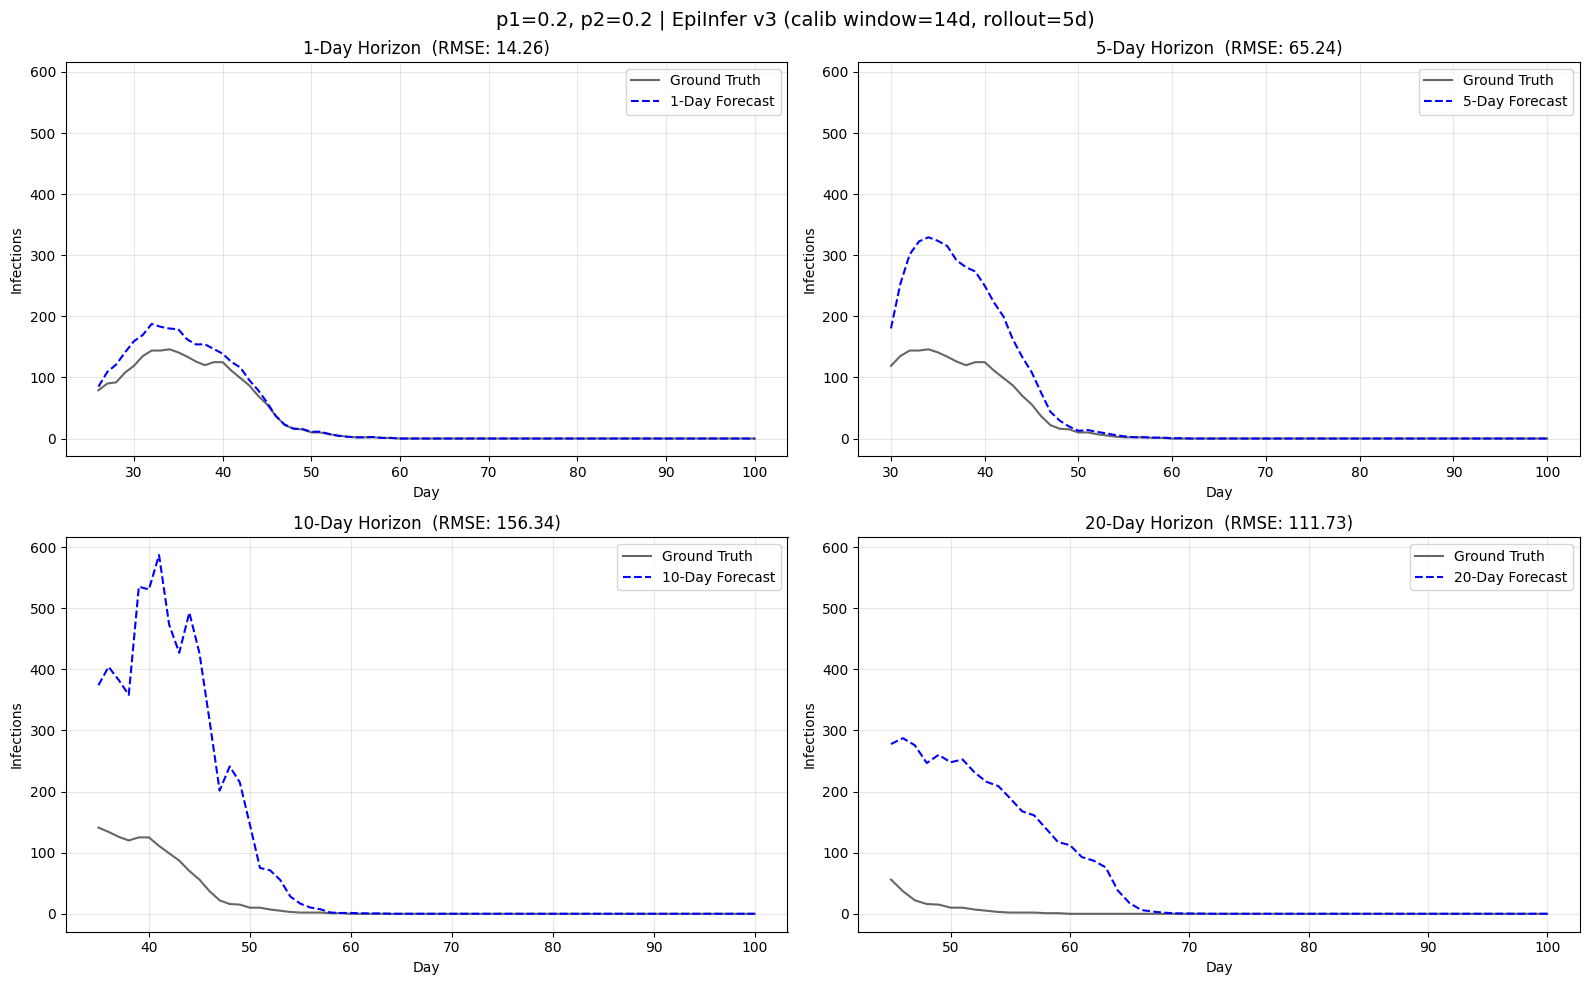

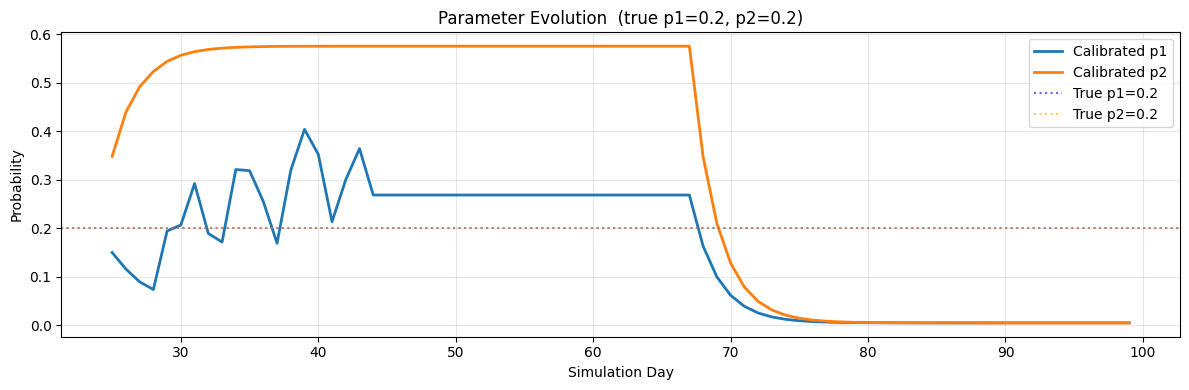


Case: p1=0.25, p2=0.1  |  loading p1_0.25_p2_0.1
  Day  25 | p1=0.2700 (true=0.25) | p2=0.2900 (true=0.1)
  Day  30 | p1=0.3853 (true=0.25) | p2=0.5528 (true=0.1)
  Day  35 | p1=0.2523 (true=0.25) | p2=0.5733 (true=0.1)
  Day  40 | p1=0.1953 (true=0.25) | p2=0.5746 (true=0.1) [FROZEN]
  Day  45 | p1=0.1953 (true=0.25) | p2=0.5746 (true=0.1) [FROZEN]
  Day  50 | p1=0.1953 (true=0.25) | p2=0.5746 (true=0.1) [FROZEN]
  Day  55 | p1=0.1953 (true=0.25) | p2=0.5746 (true=0.1) [FROZEN]
  Day  60 | p1=0.1953 (true=0.25) | p2=0.5746 (true=0.1) [FROZEN]
  Day  65 | p1=0.0198 (true=0.25) | p2=0.0493 (true=0.1)
  Day  70 | p1=0.0062 (true=0.25) | p2=0.0084 (true=0.1)
  Day  75 | p1=0.0051 (true=0.25) | p2=0.0053 (true=0.1)
  Day  80 | p1=0.0050 (true=0.25) | p2=0.0050 (true=0.1)
  Day  85 | p1=0.0050 (true=0.25) | p2=0.0050 (true=0.1)
  Day  90 | p1=0.0050 (true=0.25) | p2=0.0050 (true=0.1)
  Day  95 | p1=0.0050 (true=0.25) | p2=0.0050 (true=0.1)


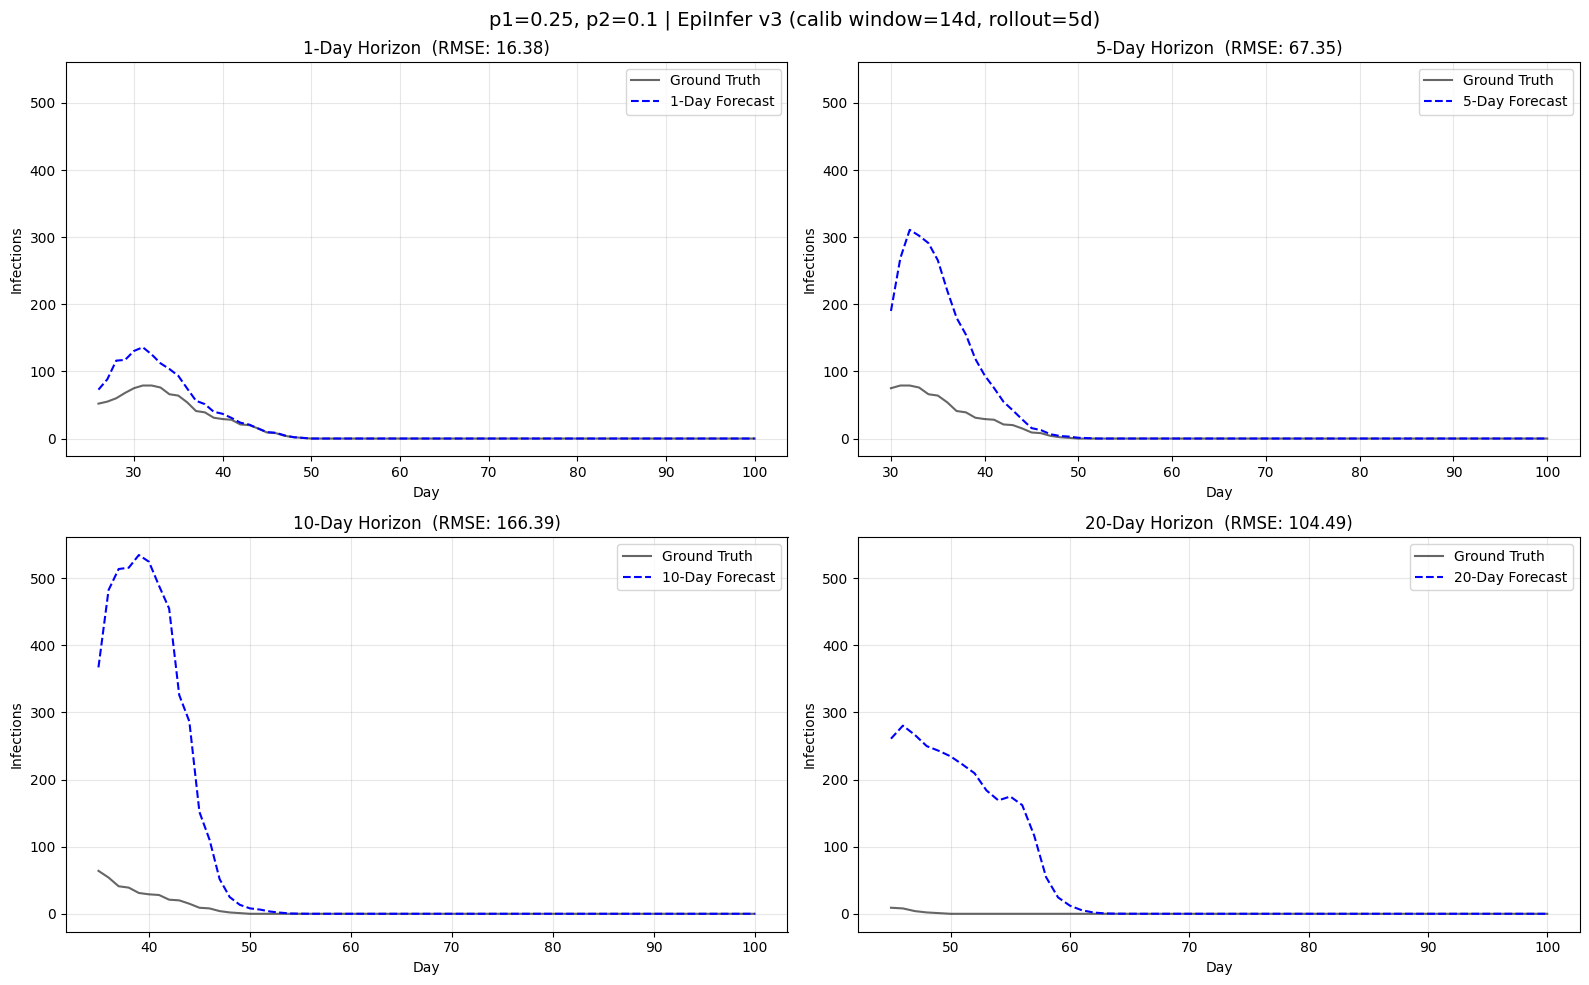

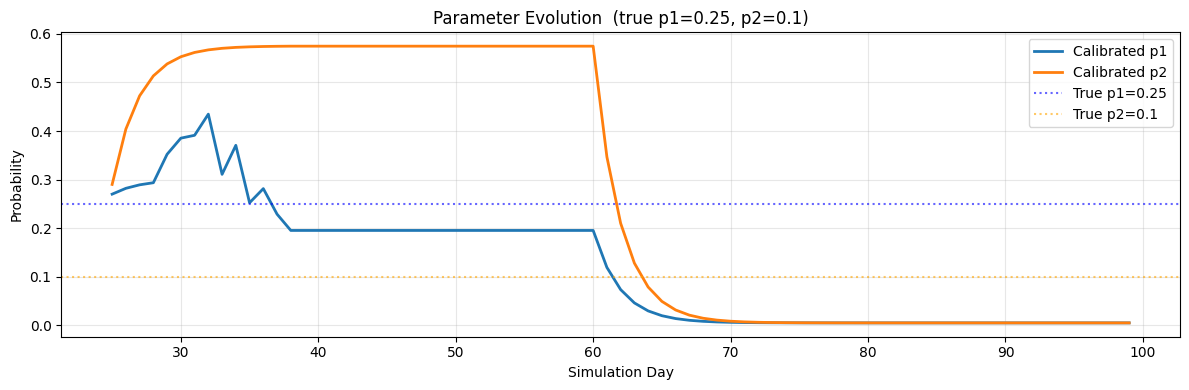


Case: p1=0.12, p2=0.1  |  loading p1_0.12_p2_0.1
  Day  25 | p1=0.1540 (true=0.12) | p2=0.2880 (true=0.1)
  Day  30 | p1=0.2474 (true=0.12) | p2=0.5493 (true=0.1)
  Day  35 | p1=0.2036 (true=0.12) | p2=0.5730 (true=0.1)
  Day  40 | p1=0.2542 (true=0.12) | p2=0.5748 (true=0.1)
  Day  45 | p1=0.4491 (true=0.12) | p2=0.5750 (true=0.1)
  Day  50 | p1=0.1808 (true=0.12) | p2=0.5750 (true=0.1)
  Day  55 | p1=0.3013 (true=0.12) | p2=0.5743 (true=0.1)
  Day  60 | p1=0.4064 (true=0.12) | p2=0.5729 (true=0.1)
  Day  65 | p1=0.2133 (true=0.12) | p2=0.5746 (true=0.1)
  Day  70 | p1=0.1703 (true=0.12) | p2=0.5750 (true=0.1)
  Day  75 | p1=0.2592 (true=0.12) | p2=0.5723 (true=0.1) [FROZEN]
  Day  80 | p1=0.1849 (true=0.12) | p2=0.5728 (true=0.1) [FROZEN]
  Day  85 | p1=0.1849 (true=0.12) | p2=0.5728 (true=0.1) [FROZEN]
  Day  90 | p1=0.1849 (true=0.12) | p2=0.5728 (true=0.1) [FROZEN]
  Day  95 | p1=0.1151 (true=0.12) | p2=0.1276 (true=0.1)


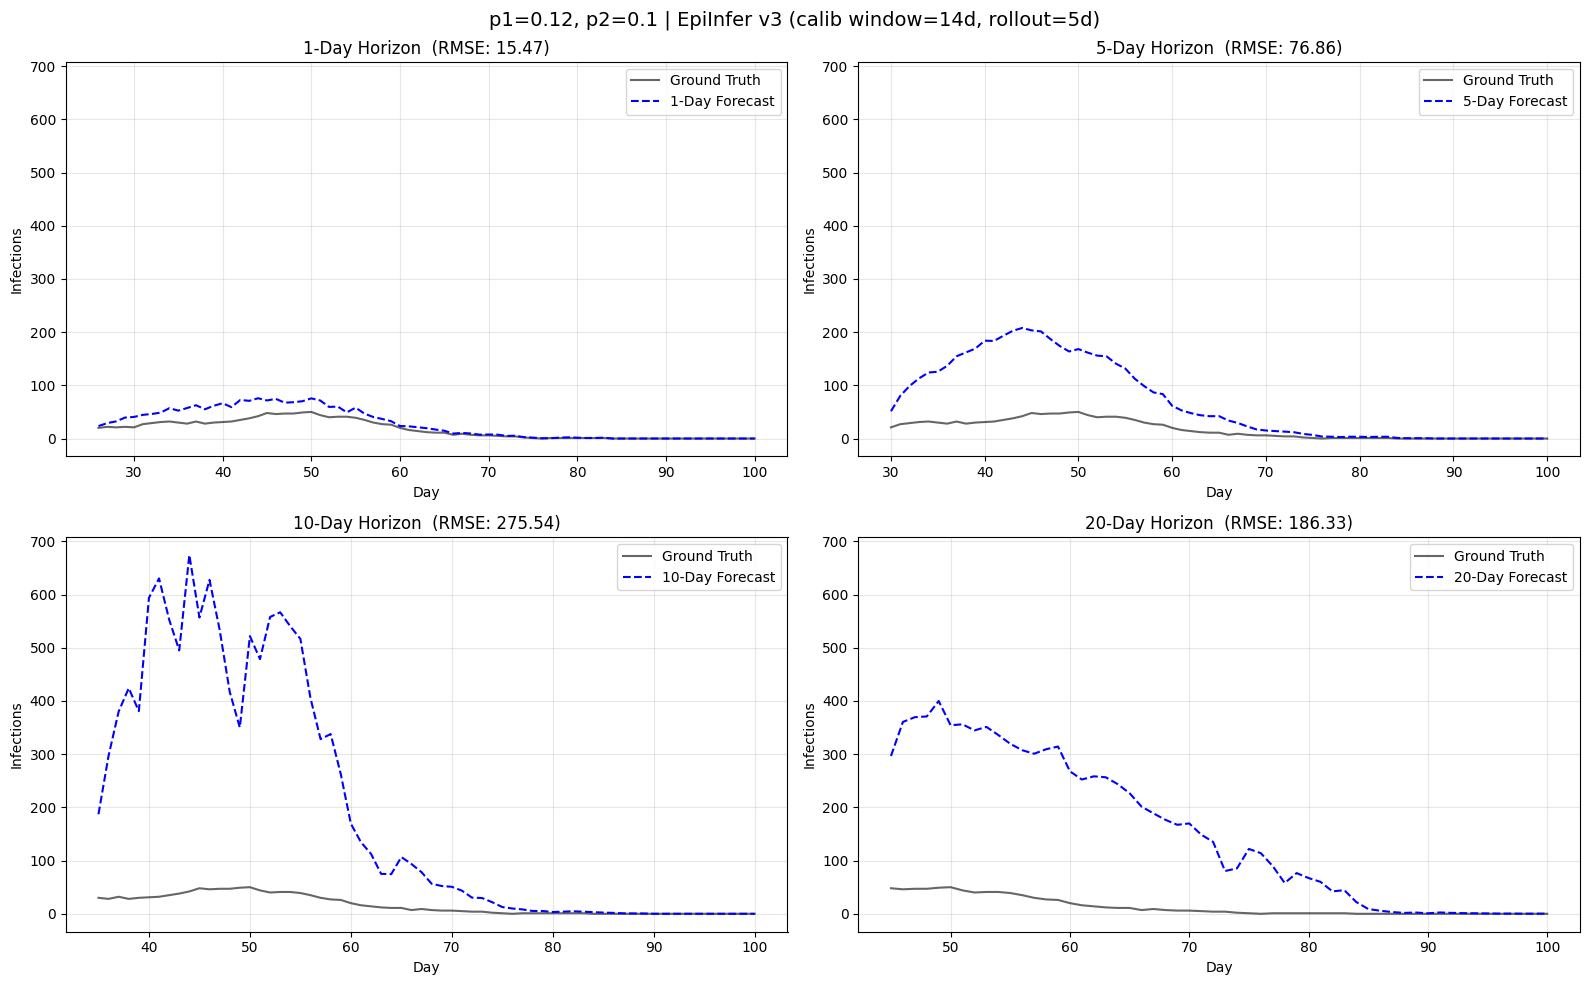

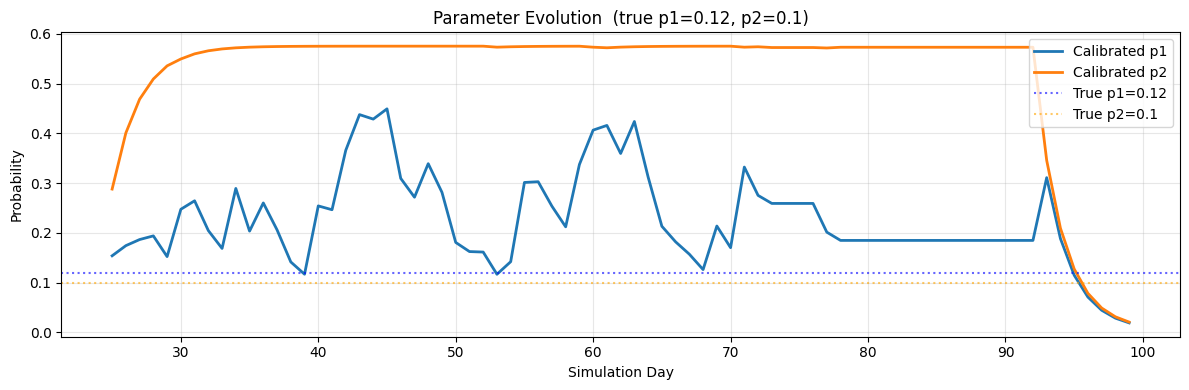


Case: p1=0.15, p2=0.05  |  loading p1_0.15_p2_0.05
  Day  25 | p1=0.1600 (true=0.15) | p2=0.2600 (true=0.05)
  Day  30 | p1=0.3620 (true=0.15) | p2=0.5505 (true=0.05)
  Day  35 | p1=0.3512 (true=0.15) | p2=0.5731 (true=0.05)
  Day  40 | p1=0.1311 (true=0.15) | p2=0.5749 (true=0.05)
  Day  45 | p1=0.2439 (true=0.15) | p2=0.5750 (true=0.05)
  Day  50 | p1=0.1958 (true=0.15) | p2=0.5750 (true=0.05)
  Day  55 | p1=0.3906 (true=0.15) | p2=0.5750 (true=0.05) [FROZEN]
  Day  60 | p1=0.4324 (true=0.15) | p2=0.5750 (true=0.05)
  Day  65 | p1=0.4118 (true=0.15) | p2=0.5311 (true=0.05) [FROZEN]
  Day  70 | p1=0.4118 (true=0.15) | p2=0.5311 (true=0.05) [FROZEN]
  Day  75 | p1=0.4118 (true=0.15) | p2=0.5311 (true=0.05) [FROZEN]
  Day  80 | p1=0.0837 (true=0.15) | p2=0.1105 (true=0.05)
  Day  85 | p1=0.0111 (true=0.15) | p2=0.0132 (true=0.05)
  Day  90 | p1=0.0055 (true=0.15) | p2=0.0056 (true=0.05)
  Day  95 | p1=0.0050 (true=0.15) | p2=0.0050 (true=0.05)


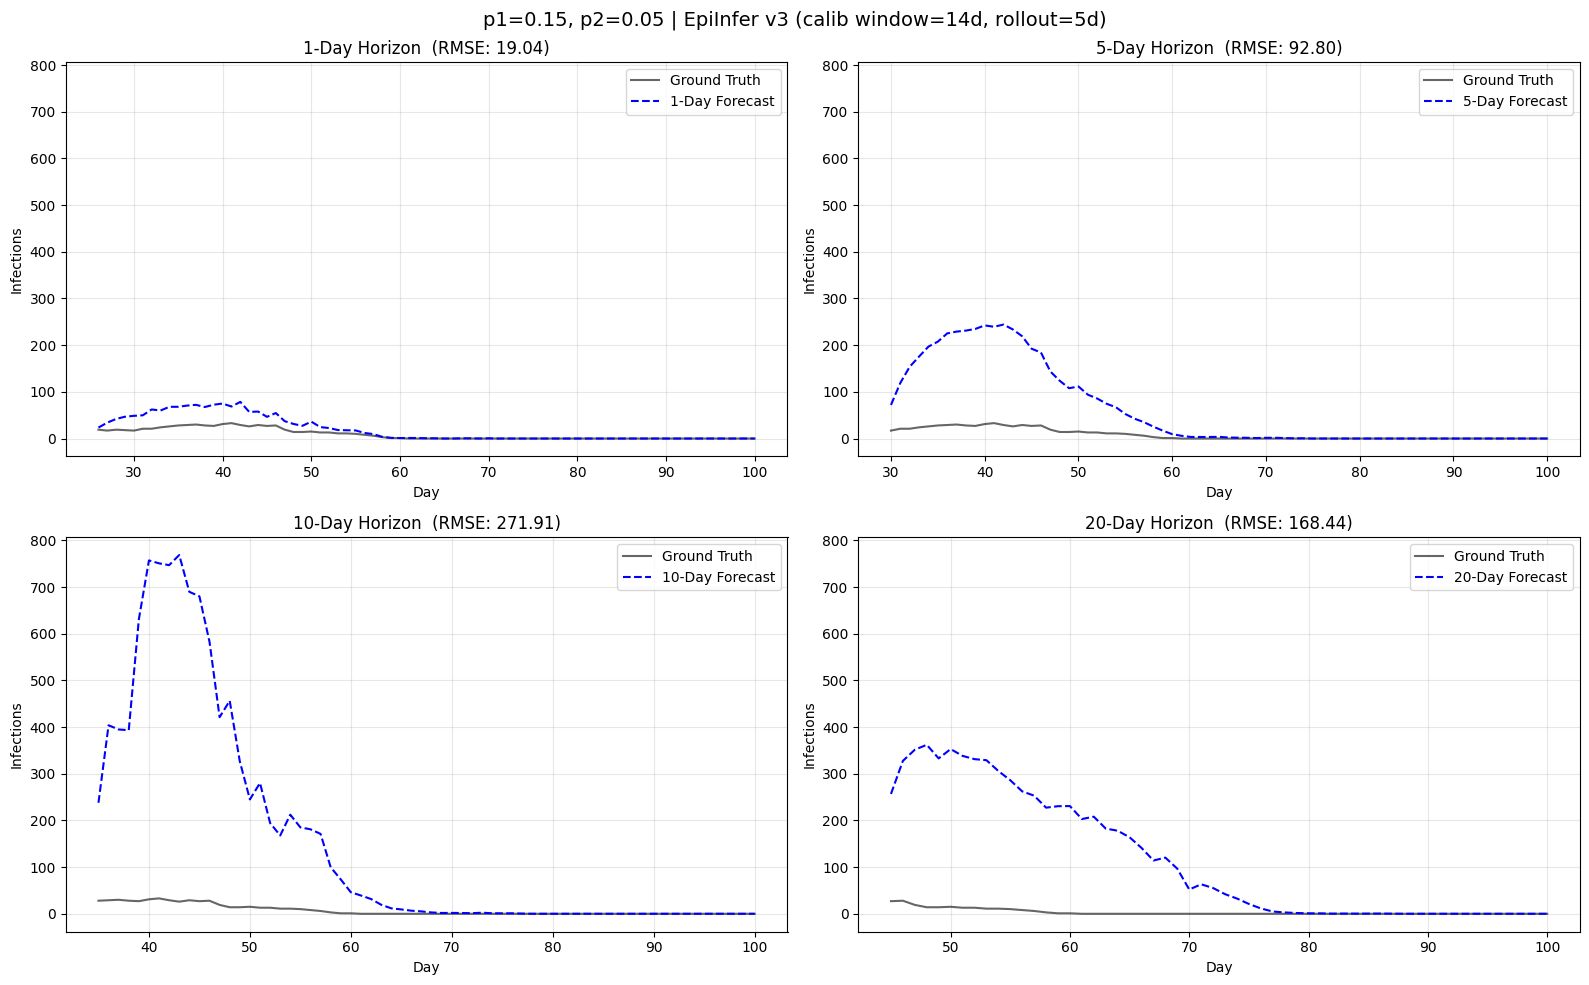

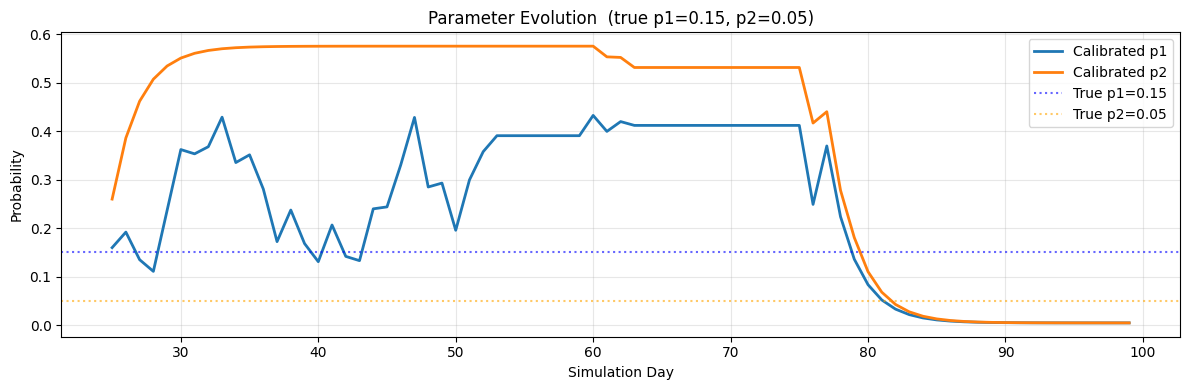


Case: p1=0.2, p2=0.1  |  loading p1_0.2_p2_0.1
  Day  25 | p1=0.3080 (true=0.2) | p2=0.2900 (true=0.1)
  Day  30 | p1=0.4200 (true=0.2) | p2=0.5528 (true=0.1)


In [ ]:
# =============================================================================
# SECTION 5 — MAIN ROLLING PREDICTION LOOP (v3)
# =============================================================================

# --- Configuration ---
horizons          = [1, 5, 10, 20]
start_eval        = 25
max_day           = 100
total_population  = 2000
calib_window      = 14
num_simulations   = 100     # MC runs for final forecast
rollout_steps_cal = 5       # multi-step rollout in calibration RMSE
num_calib_mc      = 3       # FIX E: MC runs per grid point in calibration
perturb_rate      = 0.05
dampening_alpha   = 0.4     # FIX B: EWA weight on new grid-search target

print("Starting Rolling Prediction — EpiInfer v3 (Deep Fixes)…\n")

for p1_true, p2_true in p_array:
    base_path = f'p1_{p1_true}_p2_{p2_true}'
    print(f"\n{'='*60}")
    print(f"Case: p1={p1_true}, p2={p2_true}  |  loading {base_path}")
    print('='*60)

    try:
        df_status   = pd.read_csv(f'{base_path}/individual_day_state.csv')
        df_contacts = pd.read_csv(f'{base_path}/timed_edges.csv')
    except FileNotFoundError:
        raise FileNotFoundError(
            f"Data files not found at {base_path}. "
            "Run the simulation section first.")

    # --- Ground truth: both I counts and E+I combined ---
    df_gt = (df_status
             .groupby(['day', 'state'])
             .size()
             .unstack(fill_value=0)
             .reset_index())
    for col in ['E', 'I', 'A']:
        if col not in df_gt.columns:
            df_gt[col] = 0

    ground_truth_I  = dict(zip(df_gt['day'], df_gt['I']))
    # FIX D: use E+I (total active disease burden) as calibration target
    ground_truth_EI = dict(zip(df_gt['day'], df_gt['E'] + df_gt['I']))

    # --- State sets per day ---
    all_days   = sorted(df_status['day'].unique())
    state_sets = {}
    for d in all_days:
        day_data = df_status[df_status['day'] == d]
        state_sets[d] = {
            'exposed':   set(day_data[day_data['state'] == 'E']['node']),
            'infected':  set(day_data[day_data['state'] == 'I']['node']),
            'recovered': set(day_data[day_data['state'] == 'R']['node']),
        }

    # --- New-cohort history ---
    global_new_asymp: dict = {}
    global_new_inf:   dict = {}
    for d in all_days:
        curr_E = state_sets[d]['exposed']
        curr_I = state_sets[d]['infected']
        if d == 0:
            global_new_asymp[0] = curr_E
            global_new_inf[0]   = curr_I
        else:
            global_new_asymp[d] = curr_E - state_sets[d - 1]['exposed']
            global_new_inf[d]   = curr_I - state_sets[d - 1]['infected']

    # --- Contact dict ---
    master_contacts: dict = {}
    for day, group in df_contacts.groupby('day'):
        master_contacts[day] = list(zip(group['u'], group['v']))

    population_ids = list(range(total_population))
    model = EpiInferContactRolling(population_ids, master_contacts, 7, 7)

    recovered_sets_map = {d: state_sets[d]['recovered'] for d in state_sets}

    # --- Rolling loop ---
    rows          = []
    current_p1    = p1_true
    current_p2    = p2_true
    calib_history = []

    for current_day in range(start_eval, max_day):

        # FIX D: calibration training uses E+I, not I alone
        calib_start    = max(0, current_day - calib_window)
        calib_training = {
            d: ground_truth_EI.get(d, 0)
            for d in range(calib_start, current_day + 1)
        }

        # Run calibration (FIX B+C+D+E+F all applied inside)
        best_p1, best_p2 = model.continuous_calibrate(
            training_data        = calib_training,
            training_days_window = calib_window,
            full_history_asymp   = global_new_asymp,
            full_history_inf     = global_new_inf,
            full_recovered_sets  = recovered_sets_map,
            current_day          = current_day,
            prev_p1              = current_p1,
            prev_p2              = current_p2,
            dampening_alpha      = dampening_alpha,
            rollout_steps        = rollout_steps_cal,
            num_calib_mc         = num_calib_mc,
        )
        current_p1 = best_p1
        current_p2 = best_p2
        calib_history.append({'day': current_day, 'p1': best_p1, 'p2': best_p2})

        # History buffers (FIX 1 from v2: full lookback)
        lookback = model.inc + model.duration + 1  # = 15
        h_asymp  = {k: global_new_asymp[k]
                    for k in range(current_day - lookback, current_day + 1)
                    if k in global_new_asymp}
        h_inf    = {k: global_new_inf[k]
                    for k in range(current_day - lookback, current_day + 1)
                    if k in global_new_inf}
        seed_rec = state_sets[current_day]['recovered']

        end_pred_day = min(current_day + max(horizons) + 1, max_day)

        # Monte-Carlo forecast
        aggregated: dict[int, float] = {}
        for _ in range(num_simulations):
            ph, pi = model._perturb_history(
                h_asymp, h_inf, model.population, perturb_rate=perturb_rate)
            res = model.contact_infer_core_with_history(
                best_p1, best_p2, ph, pi, current_day, end_pred_day, seed_rec)
            for d_target, val in res.items():
                aggregated[d_target] = aggregated.get(d_target, 0.0) + val

        averaged = {k: v / num_simulations for k, v in aggregated.items()}

        # Evaluate against I only (ground truth metric stays I)
        for h in horizons:
            tgt = current_day + h
            if tgt in averaged:
                rows.append({
                    'horizon':     h,
                    'current_day': current_day,
                    'target_day':  tgt,
                    'predicted':   averaged[tgt],
                    'actual':      ground_truth_I.get(tgt, 0),
                    'p1_used':     best_p1,
                    'p2_used':     best_p2,
                })

        if current_day % 5 == 0:
            frozen = model._is_declining(calib_training, current_day)
            print(f"  Day {current_day:3d} | "
                  f"p1={best_p1:.4f} (true={p1_true}) | "
                  f"p2={best_p2:.4f} (true={p2_true})"
                  + (" [FROZEN]" if frozen else ""))

    df_res = pd.DataFrame(rows)

    if df_res.empty:
        print("  No results generated.")
        continue

    # ---- Forecast plots ----
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()
    fig.suptitle(
        f'p1={p1_true}, p2={p2_true} | EpiInfer v3 '
        f'(calib window={calib_window}d, rollout={rollout_steps_cal}d)',
        fontsize=14)

    all_actual    = df_res['actual'].values
    all_predicted = df_res['predicted'].values
    y_min = min(all_actual.min(), all_predicted.min())
    y_max = max(all_actual.max(), all_predicted.max())
    y_pad = 0.05 * (y_max - y_min)
    y_min -= y_pad; y_max += y_pad

    for idx, h in enumerate(horizons):
        ax  = axes[idx]
        sub = df_res[df_res['horizon'] == h]
        if sub.empty:
            continue
        ax.plot(sub['target_day'], sub['actual'],
                label='Ground Truth', color='black', alpha=0.6)
        ax.plot(sub['target_day'], sub['predicted'],
                label=f'{h}-Day Forecast', color='blue', linestyle='--')
        rmse = np.sqrt(((sub['predicted'] - sub['actual']) ** 2).mean())
        ax.set_title(f"{h}-Day Horizon  (RMSE: {rmse:.2f})")
        ax.legend(); ax.set_ylim(y_min, y_max)
        ax.set_xlabel("Day"); ax.set_ylabel("Infections")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"forecast_p1_{p1_true}_p2_{p2_true}.png")
    plt.show()

    # ---- Parameter evolution ----
    df_params = pd.DataFrame(calib_history)
    plt.figure(figsize=(12, 4))
    plt.plot(df_params['day'], df_params['p1'], label='Calibrated p1', linewidth=2)
    plt.plot(df_params['day'], df_params['p2'], label='Calibrated p2', linewidth=2)
    plt.axhline(p1_true, color='blue',   linestyle=':', alpha=0.6,
                label=f'True p1={p1_true}')
    plt.axhline(p2_true, color='orange', linestyle=':', alpha=0.6,
                label=f'True p2={p2_true}')
    plt.title(f"Parameter Evolution  (true p1={p1_true}, p2={p2_true})")
    plt.xlabel("Simulation Day"); plt.ylabel("Probability")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"params_p1_{p1_true}_p2_{p2_true}.png")
    plt.show()